# Efficient Markets

This notebook describes and tests the predictability of asset returns (autocorrelations, autoregressions, out-of-sample R², Mariano-Diebold test) and implements a simple trading strategy.

## Load Packages and Extra Functions

In [1]:
MyModulePath = joinpath(pwd(),"src")
!in(MyModulePath,LOAD_PATH) && push!(LOAD_PATH,MyModulePath)
using FinEcmt_OLS, FinEcmt_TimeSeries
using FinEcmt_MLEGMM: MLE

In [2]:
 using LinearAlgebra, Dates, DelimitedFiles, Statistics, StatsBase

using Plots
default(size = (480,320),fmt = :png)

# Load Data

Daily excess return on S&P 500.

In [3]:
xx = readdlm("Data/ReSP500Daily.csv",',',skipstart=1)
Re = Float64.(xx[:,2])
dN = Date.(xx[:,1],"yyyy-mm-dd")
xx = nothing

(Re,dN) = excise(Re,dN) #drop dates with missing values
T   = size(Re,1)
println("Sample size: $T")

Sample size: 11479


# Autocorrelations

Autocorrelation $s$ is

$\rho_s = \text{Corr}(R_t,R_{t-s})$

In large samples, $\sqrt{T}\hat{\rho}_{s}\sim N(0,1)$ if the true value is $\rho_s=0$ for all $s$.

### A Remark on the Code

The [StatsBase.jl](https://github.com/JuliaStats/StatsBase.jl) package contains methods for estimating autocorrelations (see `autocor()` below).

In [4]:
plags = 1:5        #different lags to calculate autocorrelations for
ρ     = AutoCorr(Re,plags)

printblue("autocorrelations and their t-stats:\n")
printmat(ρ,sqrt(T)*ρ;colNames=["ρ","t-stat"],rowNames=plags,cell00="lag")

autocorrelations and their t-stats:

lag         ρ    t-stat
1      -0.054    -5.768
2      -0.006    -0.624
3      -0.007    -0.786
4      -0.032    -3.436
5      -0.003    -0.278



# Autoregressions

An AR(1) is 

$R_{t}=c+a_{1}R_{t-1}+\varepsilon_{t}.$

We also consider an asymmetric AR(1) 

$R_{t} =\alpha+\beta \delta_{t-1}R_{t-1}+\gamma(1-\delta_{t-1})R_{t-1}+\varepsilon
_{t},$

where $\delta_{t-1}=1 \ \text{ if } \ R_{t-1}<0$ and zero otherwise.

Both models can be estimated by OLS.

### A Remark on the Code
- The function `OlsGM()` does OLS and reports, among other things, the variance-covariance matrix of the estimates (called `Covb` below).
- To get standard errors, we first extract the variances from the variance-covariance matrix (`diag(Covb)`) and then calculate the square roots (`sqrt.()`). Notice the dot`.` in the latter calculation: to calculate the square root of each element in the vector of variances.
- The t-stats are then just the point estimates (minus the null hypothesis, which is here 0) divided by the standard errors.

In [5]:
x  = [ones(T-1) Re[1:end-1]]            #R(t) is regressed on (1,R(t-1))
(b,_,_,Covb,) = OlsGM(Re[2:end],x)
Stdb  = sqrt.(diag(Covb))
tstat = b./Stdb

printblue("Results from an AR(1):\n")
printmat([b tstat];colNames=["coef","t-stat"],rowNames=["constant","slope"])

Results from an AR(1):

              coef    t-stat
constant     0.029     2.777
slope       -0.054    -5.775



In [6]:
δ = Re[1:end-1] .< 0        #dummy: 1 if R(t-1) < 0
x = hcat(ones(T-1), δ.*Re[1:end-1], (1.0.-δ).*Re[1:end-1])   #R(t) is regressed on (1,Q(t-1)R(t-1),[1-Q(t-1)]R(t-1))

(b,_,_,Covb,) = OlsGM(Re[2:end],x)
Stdb  = sqrt.(diag(Covb))
tstat = b./Stdb

printblue("Results from an AR(1) with dummies:\n")
printmat([b tstat];colNames=["coef","t-stat"],rowNames=["constant","slope (down)","slope (up)"])

Results from an AR(1) with dummies:

                  coef    t-stat
constant         0.004     0.266
slope (down)    -0.086    -5.666
slope (up)      -0.018    -1.131



## Recursive Estimation and Out-of-Sample R2

The next cell does recursive estimation (longer and longer sample) and predicts one period ahead (outside of the sample). The performance of this prediction model is measured by an "out-of-sample" $R_{OOS}^2$ defined as 

$R_{OOS}^2 = 1- \frac{\text{MSE(forecasting model)}}{\text{MSE(benchmark forecast)}}$

### A Remark on the Code

- The code loops over `t=100:Tb` where `Tb` is the effective length of the sample. Inside the loop we use data on `y[1:t-1]` and `x[1:t-1,:]`. This means that the first estimation uses the first 99 observations, the second estimation the first 100 observations and so forth. After the loop, we discard the first 100 observations from the output since they are just `NaN`.
- For estimation we use the basic OLS function `OlsM()`. Clearly, `OlsGMFn()` gives the same results (but is a tiny bit slower).

In [7]:
y   = Re[2:end]     #traditional symbol for the LHS variable
Tb  = length(y)     #length of the effective sample
dNb =  dN[2:end]

x   = hcat(ones(Tb), δ.*Re[1:end-1], (1.0.-δ).*Re[1:end-1])     #predictors

(ϵ,e) = (fill(NaN,Tb),fill(NaN,Tb))
for t in 100:Tb
    local b
    b,    = OlsGM(y[1:t-1],x[1:t-1,:])    #estimate on sample 1:t-1
    ϵ[t] = y[t] - x[t,:]'b         #forecast error for t, model
    e[t] = y[t] - mean(y[1:t-1])   #forecast error for t, historical average
end
(ϵ,e,dNb) = (ϵ[100:end],e[100:end],dNb[100:end])    #drop periods without forecasts

MSE_Model = mean(abs2,ϵ)    #MSE for out-of-sample forecasts, same as mean(ϵ.^2) but quicker
MSE_Bench = mean(abs2,e)
R2oos     = 1 - MSE_Model/MSE_Bench

printblue("Performance of out-of-sample forecasting:\n")
printmat([MSE_Model;MSE_Bench;R2oos];rowNames=["MSE of AR(1)","MSE of hist avg","R2_oos"])

Performance of out-of-sample forecasting:

MSE of AR(1)        1.250
MSE of hist avg     1.245
R2_oos             -0.004



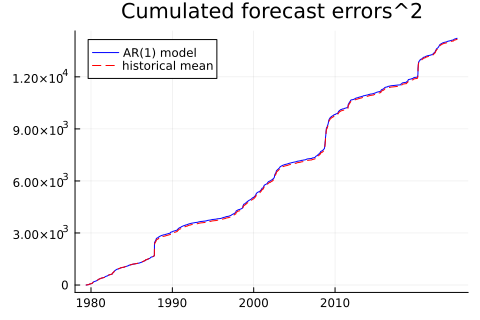

In [8]:
xTicksLoc = [Date(1980);Date(1990);Date(2000);Date(2010)]
xTicksLab = Dates.format.(xTicksLoc,"Y")     #formatting of date axis

p2 = plot( dNb,[cumsum(ϵ.^2) cumsum(e.^2)],
      linecolor = [:blue :red],
      linestyle = [:solid :dash],
      label = ["AR(1) model" "historical mean"],
      legend = :topleft,
      xticks = (xTicksLoc,xTicksLab),
      title = "Cumulated forecast errors^2" )
display(p2)

## Mariano-Diebold and Clark-West Tests

The Mariano-Diebold and Clark-West tests compare the prediction errors of two models ($e$: benchmark; $\epsilon$: your model). Notice that the Mariano-Diebold test is not well suited for nested models (when your model is an augmented version of the baseline model). Use the Clark-West in that case.

If $g_1 = e^2$ and $g_2=\epsilon^2$ are not autocorrelated, then the standard deviation of the sample average is Std$(g_i)/\sqrt{T}$. For simplicity, this assumption is used below. (Otherwise, use a Newey-West estimator or similar.)

In [9]:
"""
    MDCW(e,ϵ)

Moment conditions doing MD or CW tests of two series of forrecast errors (e: benchmark, ϵ: from the larger (superset) model)

"""
MDCW(e,ϵ) = hcat(e.^2 - ϵ.^2, 2*e.*(e - ϵ))   #Mariano-Diebold and Clark&West

MDCW

In [10]:
g  = MDCW(e,ϵ)          #e,ϵ are from the recursive estimation (above)
Tg = size(g,1)

μ      = mean(g,dims=1)
Stdμ   = std(g,dims=1)/sqrt(Tg)
tstats = μ./Stdμ

printblue("t-stats of tests of difference in performance (errors^2)\n")
printmat(tstats';rowNames=["Mariano-Diebold","Clark-West"])

t-stats of tests of difference in performance (errors^2)

Mariano-Diebold    -0.481
Clark-West          0.495



# A Trading Strategy

This section implements a momentum strategy (buy past winners, short sell past losers), which is rebalanced daily. For simplicity, we disregard trading costs.

## Implementing the Strategy

1. Rank the 25 assets according to the lagged return $R_{t-1}$.
2. (In the evening of) period  $t-1$  buy 1/5 of each of the 5 best assets based on the ranking in point 1. Similarly, buy -1/5 (short-sell) each of the 5 worst assets. Collect these portfolio weights in a vector $w_{t}$.
3. In period  $t$ , the return on the portfolio is $R_{p,t}=w_{t}'R_{t}$.
4. Repeat for all periods

### A Remark on the Code
- With `x = [9,7,8]`, the `rankPs(x)` function (see below) gives the output `[3,1,2]`. This says, for instance, that `7` is the lowest number (rank 1).
- The portfolio weights are not stored for use outside the loop. Only the strategy (portfolio) return is.

## Loading Data

The data set contains daily data of the equity market return, riskfree rate and the returns of the 25 Fama-French portfolios. All returns are in percent.

In [11]:
x   = readdlm("Data/MomentumSR.csv",',')
dN  = Date.(x[:,1],"yyyy-mm-dd")
x   = Float64.(x[:,2:end])
(Rm,Rf,R) = (x[:,1],x[:,2],x[:,3:end])

println("size of dN, Rm, Rf, R")
println(size(dN),"\n",size(Rm),"\n",size(Rf),"\n",size(R))

Re25 = R .- Rf              #excess returns
Rme  = Rm .- Rf

(T,n) = size(Re25);          #number of periods and assets

size of dN, Rm, Rf, R
(11598,)
(11598,)
(11598,)
(11598, 25)


In [12]:
"""
    rankPs(x)

Calculates the ordinal rank of eack element in a vector `x`. As an aternative,
use `ordinalrank` from the `StatsBase.jl` package.

"""
rankPs(x) = invperm(sortperm(x))

rankPs

In [13]:
m = 5   #number of assets in long/short leg of portfolio
L = 22  #window of signal starts here

Rₚ = fill(NaN,T)
for t in L+1:T           #loop over periods, save portfolio returns
    #local r,w,z       #local/global is needed in script
    z     = vec(mean(Re25[t-L:t-1,:],dims=1))
    r     = rankPs(z)
    w     = -(r.<=m)/m + ((n-m+1).<=r)/m      #short, long leg
    Rₚ[t] = w'Re25[t,:]            #same as sum(w.*R[t,:])
end

Rₚ = Rₚ[L+1:end];

We calculate the mean (excess) return, its standard deviation and the Sharpe ratio. Annualising is done by assuming 250 trading days per year (means are multiplied by 250 and standard deviation by $\sqrt{250}$). Compare with the excess return on passively holding an equity market index.

In [14]:
μ = mean(Rₚ)                 #strategy
σ = std(Rₚ)

Rme = Rm - Rf                #market
μₘ  = mean(Rme[L+1:end])
σₘ  = std(Rme[L+1:end])

printblue("Annualised results:\n")
result  = [μ*250;σ*sqrt(250);μ/σ*sqrt(250)]
resultₘ = [μₘ*250;σₘ*sqrt(250);μₘ/σₘ*sqrt(250)]
printmat(result,resultₘ,colNames=["Strategy","market"],rowNames=["mean","std","SR"])

Annualised results:

      Strategy    market
mean     9.510     8.836
std     11.160    17.334
SR       0.852     0.510



To cumulate the returns to a return index, use $(1+R_1)$, $(1+R_1)(1+R_2)$, etc. However, this does not work for excess returns, so convert them to net returns by adding the riskfree rate.

It is often more useful to show the logarithm of the return index. The slope can then be interpreted as a return.

In [15]:
Rbₚ = Rₚ + Rf[L+1:end]                #add Rf to make it a net return

Vₚ = cumprod(1 .+ Rbₚ/100)            #cumulate to return index ("value")
Vₘ = cumprod(1 .+ Rm[L+1:end]/100);  #notice /100 since percentage returns

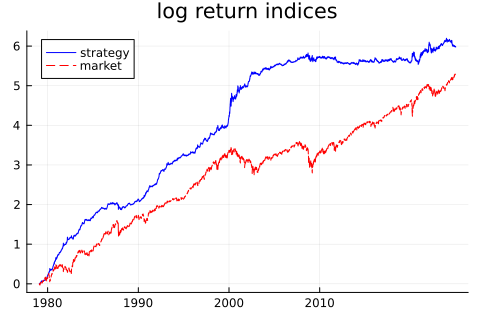

In [16]:
xTicksLoc = [Date(1980);Date(1990);Date(2000);Date(2010)]
xTicksLab = Dates.format.(xTicksLoc,"Y")

plot( dN[L+1:end],log.([Vₚ Vₘ]),
      linecolor = [:blue :red],
      linestyle = [:solid :dash],
      label = ["strategy" "market"],
      legend = :topleft,
      xticks = (xTicksLoc,xTicksLab),
      title = "log return indices" )